In [55]:

import re 
import string
import random 
import warnings
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from src.config.constants import CONFIG


import mlflow
import dagshub

import nltk
from textblob import TextBlob
from nltk.stem import WordNetLemmatizer



from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

random.seed(42)
warnings.filterwarnings('ignore')


In [56]:

df = pd.read_csv("IMDB.csv")
df.head(2)


,review,sentiment
0,Film version of Sandra Bernhard's one-woman of...,negative
1,I switched this on (from cable) on a whim and ...,positive


In [57]:

df.size


2000

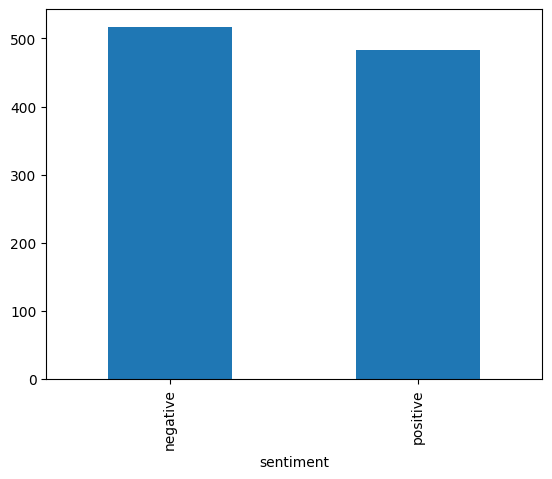

In [58]:


df["sentiment"].value_counts().plot(kind="bar")
plt.show()


In [59]:

df.isnull().sum()


review       0
sentiment    0
dtype: int64


# 1. Text Preprocessing:


In [60]:

vocavoluray = nltk.download('wordnet')
word_net_lemmetization = WordNetLemmatizer()


[nltk_data] Downloading package wordnet to /home/yasin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [61]:


# 1. lowercassing:
def smaller(sentence):
    return sentence.lower()


# 2. remove html:
def remove_html(sentence):
    return re.sub(pattern="<.*?>",repl="",string=sentence)


# 3. remove emoji:
def removeEmoji(text):
    emoji_pattern = re.compile(
    "[" 
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags (iOS)
    "\U00002700-\U000027BF"  # Dingbats
    "\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
    "\U00002600-\U000026FF"  # Miscellaneous Symbols
    "\U0001F700-\U0001F77F"  # Alchemical Symbols
    "\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
    "]+", flags=re.UNICODE)
    ans = emoji_pattern.sub("",text)
    return ans 


# 4. remove url:
def remove_url(text):
    compile = re.compile(r"https?:\S+")
    ans = compile.sub(repl="",string=text)
    return ans 


# 5. remove punctuation:
def remv_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))


# 6. spell checking(time consuming):
def spell_checking(text):
    txtblb = TextBlob(text)
    return txtblb.correct().string


# 7. chatword treatment:
abbreviations = {
    "AFAIK": "As Far As I Know",
    "AFK": "Away From Keyboard",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "A3": "Anytime, Anywhere, Anyplace",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRT": "Be Right There",
    "BTW": "By The Way",
    "B4": "Before",
    "CU": "See You",
    "CUL8R": "See You Later",
    "CYA": "See You",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FWIW": "For What It's Worth",
    "FYI": "For Your Information",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GN": "Good Night",
    "GMTA": "Great Minds Think Alike",
    "GR8": "Great!",
    "G9": "Genius",
    "IC": "I See",
    "ICQ": "I Seek you (also a chat program)",
    "ILU": "I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "KISS": "Keep It Simple, Stupid",
    "LDR": "Long Distance Relationship",
    "LMAO": "Laugh My A.. Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "L8R": "Later",
    "MTE": "My Thoughts Exactly",
    "M8": "Mate",
    "NRN": "No Reply Necessary",
    "OIC": "Oh I See",
    "PITA": "Pain In The A..",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "QPSA": "Que Pasa?",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A.. Off",
    "SK8": "Skate",
    "STATS": "Your sex and age",
    "ASL": "Age, Sex, Location",
    "THX": "Thank You",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "WB": "Welcome Back",
    "WTF": "What The F...",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "W8": "Wait...",
    "7K": "Sick:-D Laugher",
    "TFW": "That feeling when",
    "MFW": "My face when",
    "MRW": "My reaction when",
    "IFYP": "I feel your pain",
    "LOL": "Laughing out loud",
    "TNTL": "Trying not to laugh",
    "JK": "Just kidding",
    "IDC": "I don’t care",
    "ILY": "I love you",
    "IMU": "I miss you",
    "ADIH": "Another day in hell",
    "ZZZ": "Sleeping, bored, tired",
    "WYWH": "Wish you were here",
    "TIME": "Tears in my eyes",
    "BAE": "Before anyone else",
    "FIMH": "Forever in my heart",
    "BSAAW": "Big smile and a wink",
    "BWL": "Bursting with laughter",
    "LMAO": "Laughing my a** off",
    "BFF": "Best friends forever",
    "CSL": "Can’t stop laughing"
}

def chatword(txt):
    new_txt = []
    for word in txt.split(" "):
        key = word.upper()
        if key in abbreviations:
            new_txt.append(abbreviations[key].lower())
        else:
            new_txt.append(word)
    return " ".join(new_txt)




# 8. Stemming or Lemmitization:
def lemmetization(text):
    fnl_str = []
    for word in text.split(" "):
        base_wrd = word_net_lemmetization.lemmatize(word)
        fnl_str.append(base_wrd)
    return " ".join(fnl_str)





In [62]:

def apply_preprocessing(df)->pd.DataFrame:
    
    df["review"] = df["review"].apply(smaller)
    df["sentiment"] = df["sentiment"].apply(smaller)
    print("smaller done:")
    
    df["review"] = df["review"].apply(remove_html)
    print("remove html  done:")
    
    df["review"] = df["review"].apply(removeEmoji)
    print("remove emoji done:")
    
    df["review"] = df["review"].apply(remove_url)
    print("remove url from text done:")
    
    df["review"] = df["review"].apply(remv_punctuation)
    print("remove punctuation done:")
    
    #df["review"] = df["review"].apply(spell_checking)
    print("spell checking done:")
    
    df["review"] = df["review"].apply(chatword)
    print("chatword done:")
    
    df["review"] = df["review"].apply(lemmetization)
    print("lemmetization done:")
    return df 

df = apply_preprocessing(df)
df.head(2)


smaller done:
remove html  done:
remove emoji done:
remove url from text done:
remove punctuation done:
spell checking done:
chatword done:
lemmetization done:


,review,sentiment
0,film version of sandra bernhards onewoman offb...,negative
1,i switched this on from cable on a whim and wa...,positive


In [63]:

le = LabelEncoder()
df["sentiment"] = le.fit_transform(df["sentiment"])
df.head(2)


,review,sentiment
0,film version of sandra bernhards onewoman offb...,0
1,i switched this on from cable on a whim and wa...,1


In [64]:
le.classes_

array(['negative', 'positive'], dtype=object)

<br>
<br>

# 2. mlflow-tracking and model tranning:

<br>
<br>


In [65]:


mlflow.set_tracking_uri(CONFIG.MLFLOW_DAGSHUB_TRACKING_URI)
dagshub.init(repo_name=CONFIG.DAGSHUB_REPO_NAME,repo_owner=CONFIG.DAGSHUB_REPO_OWNER,mlflow=True)



Initialized MLflow to track repo "ug2102030/sentiment_end_2_end"

Repository ug2102030/sentiment_end_2_end initialized!

In [66]:

test_size = 0.3 

X_train,X_test,y_train,y_test = train_test_split(df["review"],df["sentiment"],test_size=test_size,
                                                 random_state=42)

print(f"X_train: {X_train.shape} ,y_train: {y_train.shape}")
print(f"X_test: {X_test.shape} ,y_test: {y_test.shape}")



X_train: (700,) ,y_train: (700,)
X_test: (300,) ,y_test: (300,)


In [67]:

mlflow.set_experiment("Run_with_baseline_model_logistics_regression")


<Experiment: artifact_location='mlflow-artifacts:/3f6ed5aa883d467e81e64da387b7d5f7', creation_time=1774713673352, experiment_id='0', last_update_time=1774713673352, lifecycle_stage='active', name='Run_with_baseline_model_logistics_regression', tags={}, workspace='default'>

In [71]:


with mlflow.start_run():
    mlflow.log_param("test_size",test_size)
    
    # embedding:
    max_features = 500
    ngram_range = (3,3)
    mlflow.log_param("count_vectorizer_max_features",max_features)
    mlflow.log_param("count_vectorizer_ngram_range",ngram_range)
    cv  = CountVectorizer(ngram_range=ngram_range,max_features=max_features)
    X_train_vec = cv.fit_transform(X_train)
    X_test_vec = cv.transform(X_test)
    
    # model tranning 
    peanlty = "l2"
    max_iter = 200
    mlflow.log_param("peanlty",peanlty)
    mlflow.log_param("max_iter",max_iter)
    lr = LogisticRegression(penalty=peanlty,max_iter=max_iter,verbose=True)
    lr.fit(X_train_vec,y_train)
    
    
    # prediction on tranning data
    pred = lr.predict(X_train_vec)
    acc = accuracy_score(y_train,pred)
    f1 = f1_score(y_train,pred) 
    precision = precision_score(y_train,pred)
    recall = recall_score(y_train,pred) 
    
    mlflow.log_metric("train accuracy score",acc)
    mlflow.log_metric("train f1 score",f1)
    mlflow.log_metric("train precision score",precision)
    mlflow.log_metric("train recall",recall)
    
    print(f"Train accuracy score: ",acc)
    print(f"Train accuracy f1 score: ",f1)
    print(f"Train accuracy precision score: ",precision)
    print(f"Train accuracy recall score: ",recall)
    
    
    # prediction on testing data
    pred = lr.predict(X_test_vec)
    acc = accuracy_score(y_test,pred)
    f1 = f1_score(y_test,pred) 
    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred) 
    
    mlflow.log_metric("test accuracy score",acc)
    mlflow.log_metric("test f1 score",f1)
    mlflow.log_metric("test precision score",precision)
    mlflow.log_metric("test recall",recall)
    
    print(f"Test accuracy score: ",acc)
    print(f"Test accuracy f1 score: ",f1)
    print(f"Test accuracy precision score: ",precision)
    print(f"Test accuracy recall score: ",recall)
    
    

Train accuracy score:  0.8957142857142857
Train accuracy f1 score:  0.8895612708018155
Train accuracy precision score:  0.8882175226586103
Train accuracy recall score:  0.8909090909090909
Test accuracy score:  0.5766666666666667
Test accuracy f1 score:  0.5723905723905723
Test accuracy precision score:  0.5902777777777778
Test accuracy recall score:  0.5555555555555556
🏃 View run dazzling-donkey-470 at: https://dagshub.com/ug2102030/sentiment_end_2_end.mlflow/#/experiments/0/runs/4cb3900f79b747c6add04b8fe27da5d4
🧪 View experiment at: https://dagshub.com/ug2102030/sentiment_end_2_end.mlflow/#/experiments/0
